In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from IPython.display import Image

In [2]:
data = {'cgpa': [8, 7, 6, 5, 9.2, 9.4], 
        'resume_score': [9, 9, 6, 7, 8.7, 8], 
        'lpa': [24, 18, 10, 12, 36, 12]}
df = pd.DataFrame(data)
df

,cgpa,resume_score,lpa
0,8.0,9.0,24
1,7.0,9.0,18
2,6.0,6.0,10
3,5.0,7.0,12
4,9.2,8.7,36
5,9.4,8.0,12


In [3]:
X_raw = np.array(df[['cgpa', 'resume_score']])
y_raw = np.array(df['lpa'])

In [4]:
X = (X_raw - np.mean(X_raw, axis=0)) / np.std(X_raw, axis=0)
y = (y_raw - np.mean(y_raw)) / np.std(y_raw)

In [5]:
df_standard = pd.DataFrame(np.column_stack((X,y)))
df_standard

,0,1,2
0,0.352867,0.940718,0.588172
1,-0.269840,0.940718,-0.073521
2,-0.892547,-1.747047,-0.955779
3,-1.515253,-0.851126,-0.735215
4,1.100116,0.671941,1.911558
5,1.224657,0.044796,-0.735215


### Network Architecture

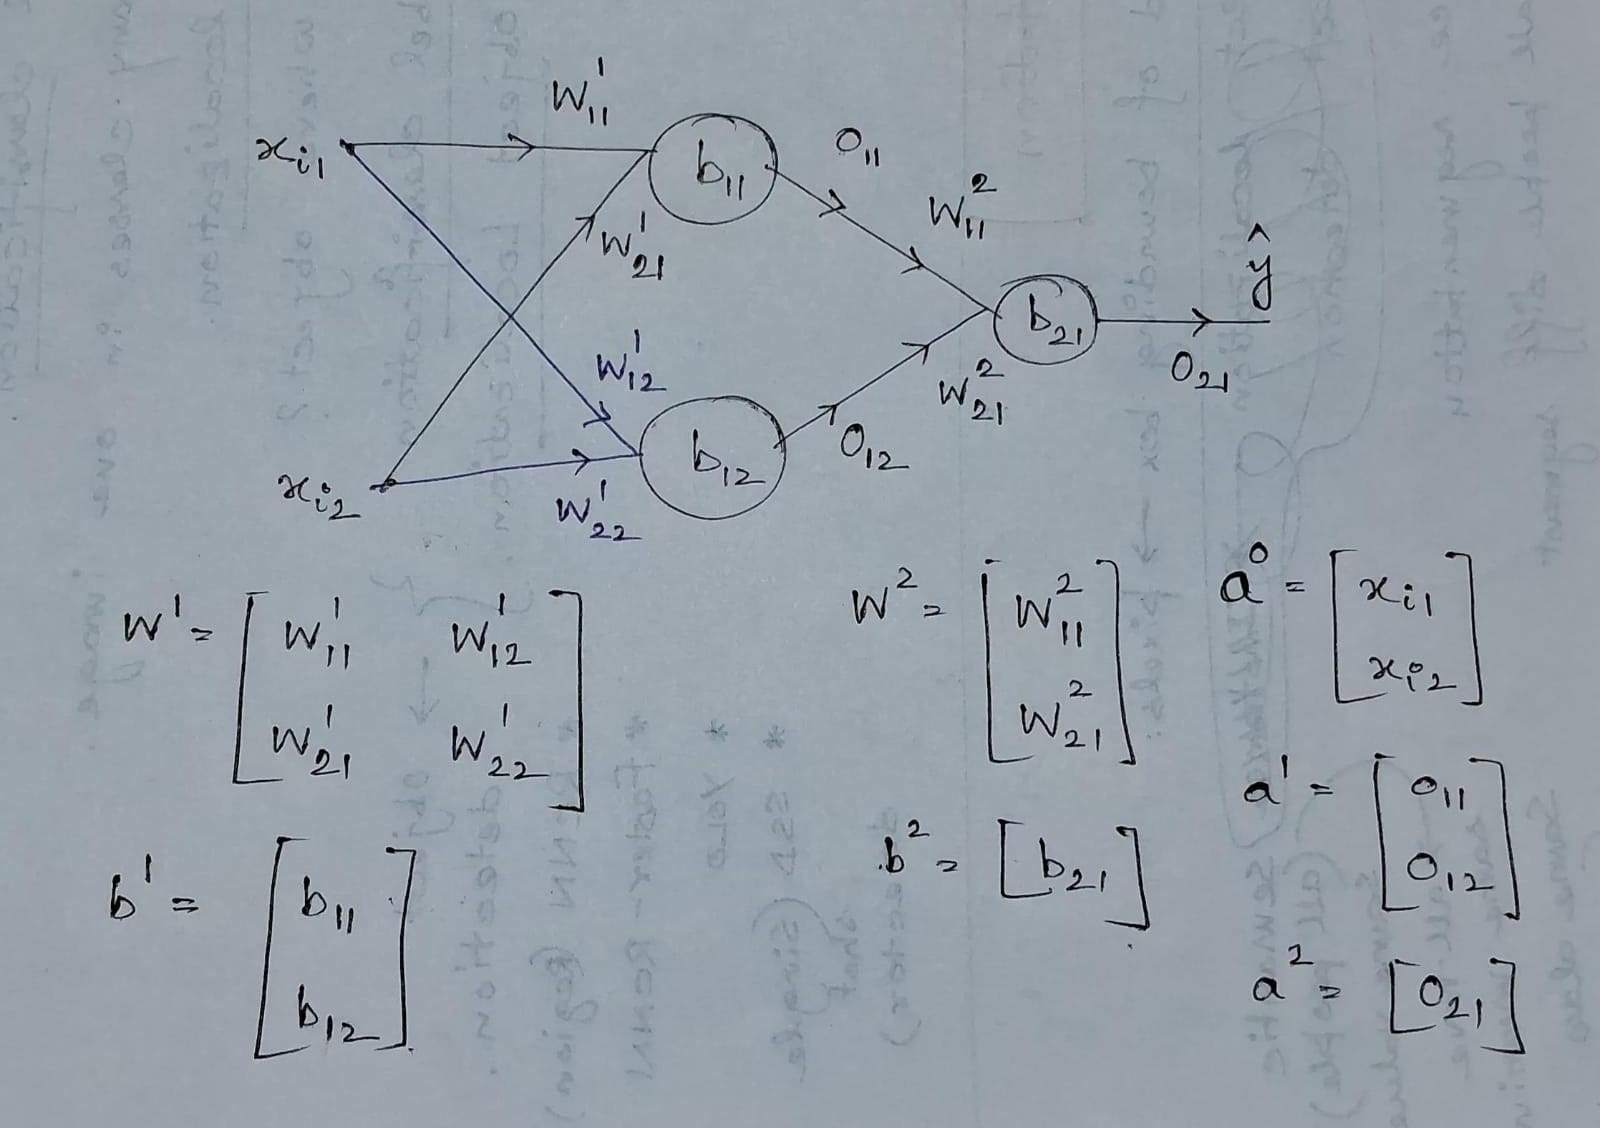

In [6]:
Image(filename='./network.jpeg') 

### Initializa Model Parameters

In [7]:
# Initializa parameters for any architecture structure given
def initialize_parameters(architecture_structure, mode='random'): # [2, 2, 1]
    np.random.seed(42)

    parameters = {}
    L = len(architecture_structure) # 3

    # in W each columns denote the weights for a particular node. W11, W21 are the weights for node 1 from x1 and x2.

    for l in range(1, L): # 1, 2
        if mode.lower() == 'random':
            parameters["W" + str(l)] = np.random.uniform(size=(architecture_structure[l-1], architecture_structure[l]))
            # W1 = [W11    W12
            #       W21    W22]
            parameters["b" + str(l)] = np.random.uniform(size=(architecture_structure[l], 1))
            # b1 = [b11
            #       b12]
        elif mode.lower() == 'constant':
            parameters["W" + str(l)] = np.ones(shape=(architecture_structure[l-1], architecture_structure[l]))
            parameters["b" + str(l)] = np.zeros(shape=(architecture_structure[l], 1))

    return parameters

In [8]:
model_params = initialize_parameters([2, 2, 1])
model_params

{'W1': array([[0.37454012, 0.95071431],
        [0.73199394, 0.59865848]]),
 'b1': array([[0.15601864],
        [0.15599452]]),
 'W2': array([[0.05808361],
        [0.86617615]]),
 'b2': array([[0.60111501]])}

### Single Node Output

In [9]:
def linear(x):
    return x

def sigmoid(x):
    return 1/(1 + np.exp(-x))

In [10]:
def compute_node_output(a_prev, W, b, activation):
    z = np.dot(W.T, a_prev) + b
    if activation.lower() == 'sigmoid':
        return sigmoid(z)
    elif activation.lower() == 'linear':
        return linear(z)
    else:
        raise ValueError("Invalid activation function. Supported functions: 'sigmoid', 'linear'.")

In [11]:
x1 = np.array(X[0].reshape(2, 1))
W1_dummy = np.array([[0.1, 0.2],[0.6, 0.7]])
b1_dummy = np.array([0.0, 0.0]).reshape(2,1)
compute_node_output(x1, W1_dummy, b1_dummy, activation='Linear')


array([[0.59971736],
       [0.72907586]])

### Forward Propagation

In [12]:
def forwardprop(x, parameters):
    L = len(parameters)//2 # W, b for each layer
    a = x

    for l in range(1, L+1):
        a_prev = a
        Wl = parameters['W' + str(l)]
        bl = parameters['b' + str(l)]
        a = compute_node_output(a_prev, Wl, bl, activation='linear')
    return a, a_prev

In [13]:
forwardprop(X[0].reshape(2, 1), model_params)

(array([[1.57135323]]),
 array([[0.97678126],
        [1.05463911]]))

### Backpropagation

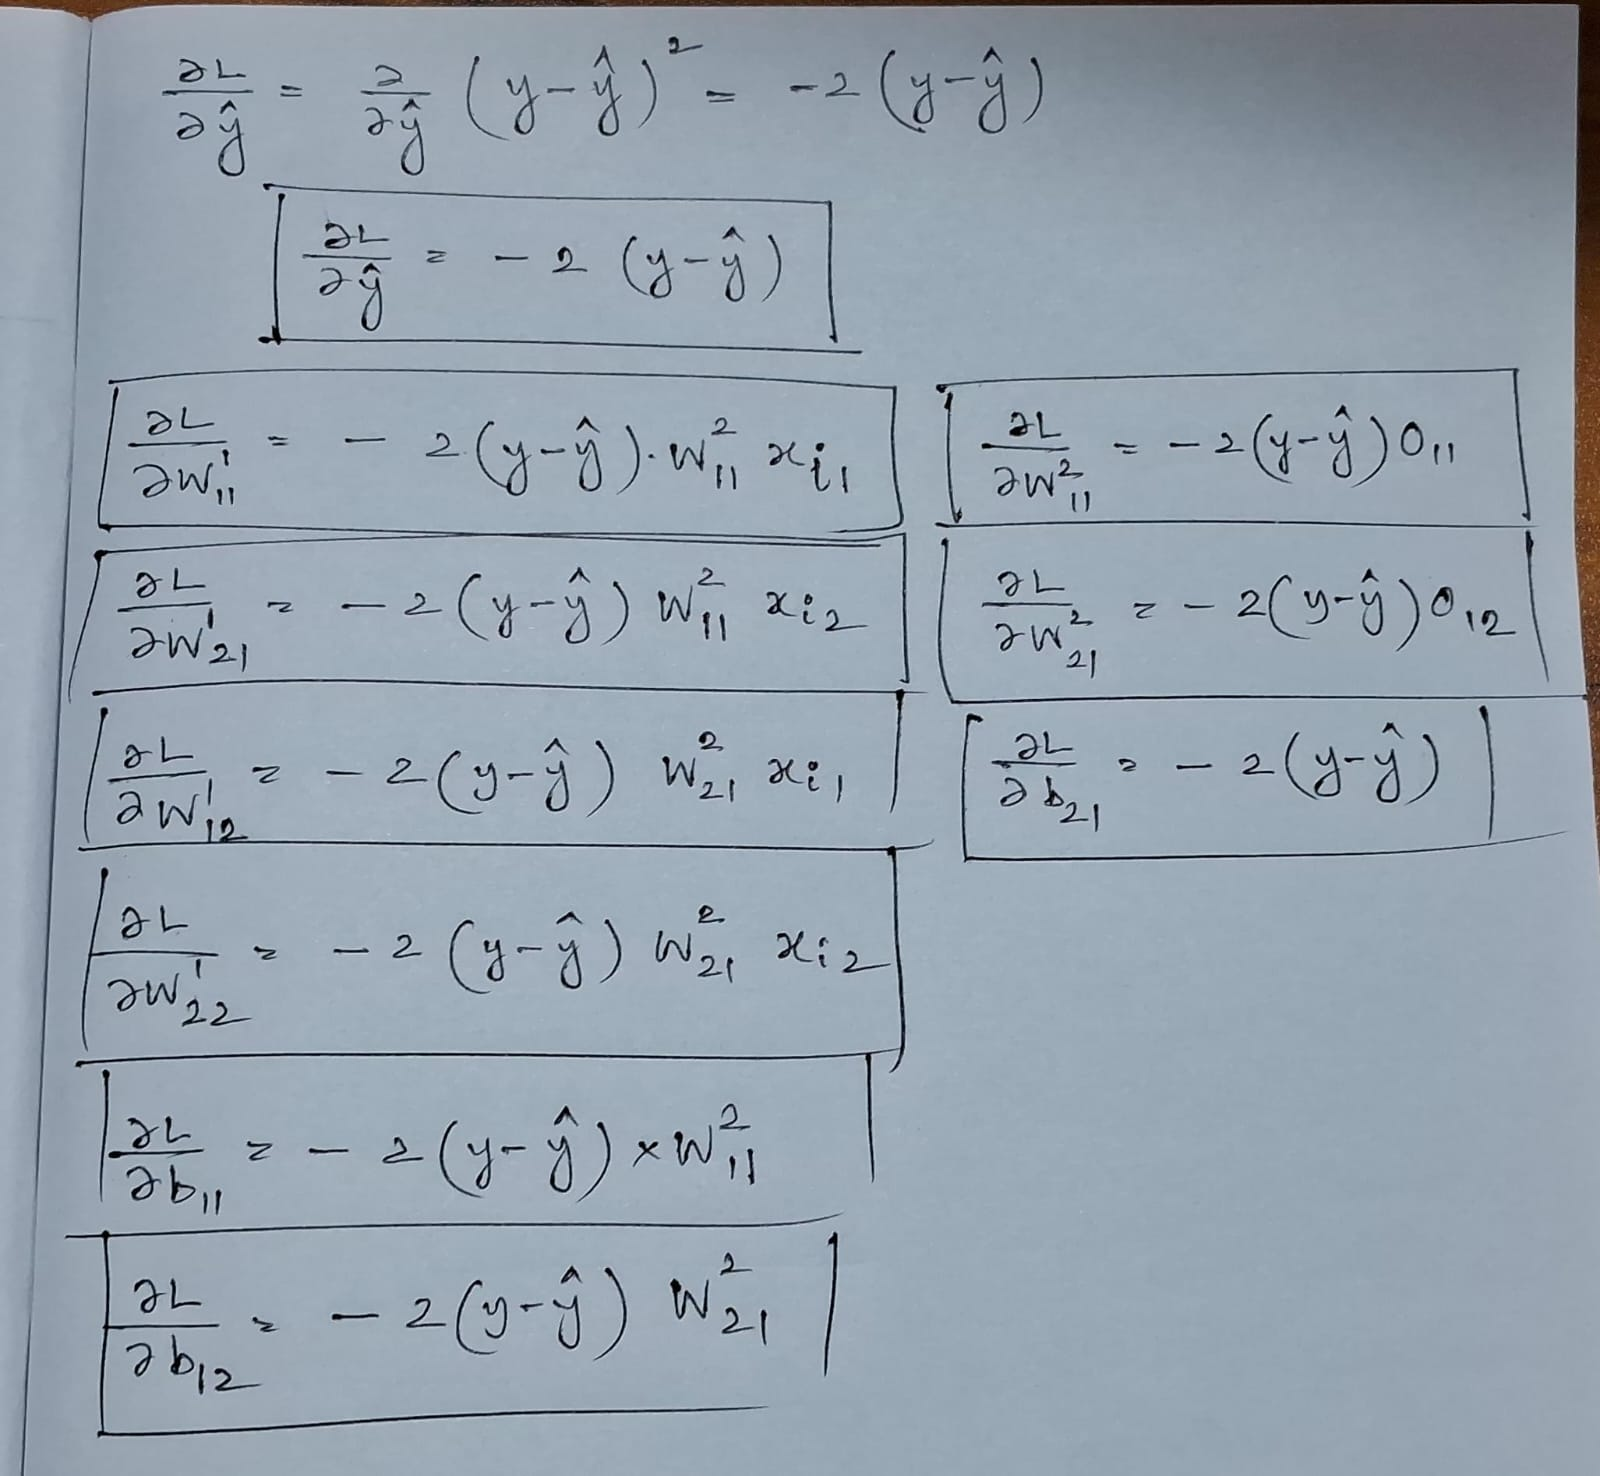

In [14]:
Image(filename='./update rules.jpeg')

In [15]:
# Explicitly for [2, 2, 1] architecture
def update_parameters(parameters, y, y_hat, x, a_prev, LR):

    dLdy_hat = (-2) * (y-y_hat)

    # Update Layer1 weights and biases using old W2 values
    parameters['W1'][0][0] -= LR * dLdy_hat * parameters['W2'][0][0] * x[0][0]
    parameters['W1'][1][0] -= LR * dLdy_hat * parameters['W2'][0][0] * x[1][0]
    parameters['W1'][0][1] -= LR * dLdy_hat * parameters['W2'][1][0] * x[0][0]
    parameters['W1'][1][1] -= LR * dLdy_hat * parameters['W2'][1][0] * x[1][0]
    parameters['b1'][0][0] -= LR * dLdy_hat * parameters['W2'][0][0]
    parameters['b1'][1][0] -= LR * dLdy_hat * parameters['W2'][1][0]

    # Update Layer2 weights and biases
    parameters['W2'][0][0] -= LR * dLdy_hat * a_prev[0][0]
    parameters['W2'][1][0] -= LR * dLdy_hat * a_prev[1][0]
    parameters['b2'][0][0] -= LR * dLdy_hat

### Fit the model with SGD

In [16]:
def fit_model(model_params, X, y, epochs, LR): # SGD
    n = X.shape[0]

    for i in tqdm(range(epochs)):
        Loss = []
        for _ in range(n):
            j = np.random.choice(n, size=1, replace=False)
            x_sample, y_sample = X[j].reshape(2, 1), y[j].item()

            y_hat, a_prev = forwardprop(x_sample, model_params)
            y_hat = y_hat.item()
        
            update_parameters(model_params, y_sample, y_hat, x_sample, a_prev, LR)
            Loss.append((y_sample-y_hat)**2)

        print(f"Epoch {i+1}/{epochs} >>>>> Loss: {sum(Loss)/len(Loss)}")

### Run the whole process

In [19]:
model_params = initialize_parameters(architecture_structure=[2,2,1], mode='random')

print(f"Initial Parameters: {model_params}")

fit_model(model_params, X, y, epochs=10, LR=0.01)

print(f"Final Parameters: {model_params}")

Initial Parameters: {'W1': array([[0.37454012, 0.95071431],
       [0.73199394, 0.59865848]]), 'b1': array([[0.15601864],
       [0.15599452]]), 'W2': array([[0.05808361],
       [0.86617615]]), 'b2': array([[0.60111501]])}


100%|██████████| 10/10 [00:00<00:00, 2426.14it/s]

Epoch 1/10 >>>>> Loss: 1.3796452745879826
Epoch 2/10 >>>>> Loss: 1.5840807973774382
Epoch 3/10 >>>>> Loss: 0.21446186773180567
Epoch 4/10 >>>>> Loss: 1.4048545841455253
Epoch 5/10 >>>>> Loss: 0.4637283859541652
Epoch 6/10 >>>>> Loss: 0.6843412703715329
Epoch 7/10 >>>>> Loss: 0.22099987597460827
Epoch 8/10 >>>>> Loss: 0.6947143717638055
Epoch 9/10 >>>>> Loss: 0.6325233921726653
Epoch 10/10 >>>>> Loss: 0.1907855853655348
Final Parameters: {'W1': array([[0.36852001, 0.83565568],
       [0.72719397, 0.5649451 ]]), 'b1': array([[ 0.1621174 ],
       [-0.08384316]]), 'W2': array([[-0.06714147],
       [ 0.69783095]]), 'b2': array([[0.28519265]])}


In [20]:
model_params = initialize_parameters(architecture_structure=[2,2,1], mode='constant')

print(f"Initial Parameters: {model_params}")

fit_model(model_params, X, y, epochs=10, LR=0.01)

print(f"Final Parameters: {model_params}")

Initial Parameters: {'W1': array([[1., 1.],
       [1., 1.]]), 'b1': array([[0.],
       [0.]]), 'W2': array([[1.],
       [1.]]), 'b2': array([[0.]])}


100%|██████████| 10/10 [00:00<00:00, 3437.67it/s]

Epoch 1/10 >>>>> Loss: 5.020598658386808
Epoch 2/10 >>>>> Loss: 1.1514539029278792
Epoch 3/10 >>>>> Loss: 0.565549106644765
Epoch 4/10 >>>>> Loss: 0.7757235791628313
Epoch 5/10 >>>>> Loss: 0.8481867277234164
Epoch 6/10 >>>>> Loss: 0.7968824647460803
Epoch 7/10 >>>>> Loss: 0.4783450713249268
Epoch 8/10 >>>>> Loss: 0.491941718875558
Epoch 9/10 >>>>> Loss: 0.2656272535798068
Epoch 10/10 >>>>> Loss: 0.5407092334034472
Final Parameters: {'W1': array([[0.70129782, 0.70129782],
       [0.74626222, 0.74626222]]), 'b1': array([[0.00779802],
       [0.00779802]]), 'W2': array([[0.28367165],
       [0.28367165]]), 'b2': array([[0.03318178]])}
